# Bayesian Inference for Mass-Action Kinetics Model

This notebook performs MCMC inference on the Mass-Action (MA), Michaelis-Menten (MM) or Hill model using PyMC with JAX backend.

Based on inference_pymc.py by Nathaniel Linden (UCSD MAE) - 2024

Edited by Annette Thompson (CU Boulder) - 2026

## Setup Environment

In [27]:
# Set XLA flags for multi-threading
import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"

## Import Libraries

In [28]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import diffrax as dfrx
import equinox as eqx
import pymc as pm
from pytensor.link.jax.dispatch import jax_funcify
import arviz as az

from jax import random
import json, os

from utils import *

# Import the model
from MA_diffrax import *
from MM_diffrax import *
from Hill_diffrax import *

# Tell JAX to use 64-bit floats
jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")
print(f"PyMC version: {pm.__version__}")
print(f"Number of JAX devices: {jax.device_count()}")

JAX version: 0.7.0
PyMC version: 5.27.1
Number of JAX devices: 4


## Set Parameters
Run one of the cells below

In [29]:
# MA model
model_name = "MA"
free_params = "k_f,k_r,k_cat"
data_file = "./Data/Duggleby_Clarke_1991_Fig2.csv"
model_info_file = "./MA_pyruvate_kinase.json"
savedir = "./MA_Results"

# Prior parameters
prior_family = "[['Gamma()',['alpha', 'beta']]]"
lower_mult = 0.1
upper_mult = 2.0

# MCMC parameters
nwarmup = 300
nsamples = 200
nchains = 4
seed = 0

# ODE solver parameters
rtol = 1e-9
atol = 1e-9
pcoeff = 0.3
icoeff = 0.4
dcoeff = 0.0

print("MA Model:")
print(f"Free parameters: {free_params}")
print(f"MCMC: {nchains} chains, {nwarmup} warmup, {nsamples} samples")

MA Model:
Free parameters: k_f,k_r,k_cat
MCMC: 4 chains, 300 warmup, 200 samples


In [101]:
# MM model
model_name = "MM"
free_params = "V_max,K_m"
data_file = "./Data/Duggleby_Clarke_1991_Fig2.csv"
model_info_file = "./MM_pyruvate_kinase.json"
savedir = "./MM_Results"

# Prior parameters
prior_family = "[['Gamma()',['alpha', 'beta']]]"
lower_mult = 0.1
upper_mult = 2.0

# MCMC parameters
nwarmup = 300
nsamples = 200
nchains = 4
seed = 0

# ODE solver parameters
rtol = 1e-9
atol = 1e-9
pcoeff = 0.3
icoeff = 0.4
dcoeff = 0.0

print("MM Model:")
print(f"Free parameters: {free_params}")
print(f"MCMC: {nchains} chains, {nwarmup} warmup, {nsamples} samples")

MM Model:
Free parameters: V_max,K_m
MCMC: 4 chains, 300 warmup, 200 samples


In [53]:
# Hill model
model_name = "Hill"
free_params = "V_max,K_m,n"
data_file = "./Data/Duggleby_Clarke_1991_Fig2.csv"
model_info_file = "./Hill_pyruvate_kinase.json"
savedir = "./Hill_Results"

# Prior parameters
prior_family = "[['Gamma()',['alpha', 'beta']],['Gamma()',['alpha', 'beta']],['TruncatedNormal(lower=1)',['mu', 'sigma']]]"
lower_mult = 0.1
upper_mult = 2.0

# MCMC parameters
nwarmup = 300
nsamples = 200
nchains = 4
seed = 0

# ODE solver parameters
rtol = 1e-10
atol = 1e-10
pcoeff = 0.3
icoeff = 0.4
dcoeff = 0.0

print("Hill Model:")
print(f"Free parameters: {free_params}")
print(f"MCMC: {nchains} chains, {nwarmup} warmup, {nsamples} samples")

Hill Model:
Free parameters: V_max,K_m,n
MCMC: 4 chains, 300 warmup, 200 samples


## Initialize Random Seed and Create Save Directory

In [90]:
# JAX PRNG key
key = random.PRNGKey(seed)

# Create save directory if it doesn't exist
if not os.path.isdir(savedir):
    os.makedirs(savedir)
    print(f"Created directory: {savedir}")
else:
    print(f"Save directory exists: {savedir}")

Save directory exists: ./MM_Results


## Load Model and Model Information

In [102]:
# Load JSON file with parameter, state, and initial condition info
with open(model_info_file, 'r') as file:
    model_info = json.load(file)

# Unpack loaded model data dictionary
state_names = list(model_info["init_conds"].keys())
sub_prod_states = model_info["sub_prod_states"]
prod_states = model_info["prod_states"]
y0 = list(model_info["init_conds"].values())

# Get the indices of the states
sub_prod_idxs = [state_names.index(item) for item in sub_prod_states]
prod_idxs = [state_names.index(item) for item in prod_states]

# Process the free parameters
free_params_list = free_params.split(',')

print(f"State names: {state_names}")
print(f"Initial conditions: {y0}")
print(f"Free parameters: {free_params_list}")
print(f"Substrate/Product states: {sub_prod_states}")
print(f"Product states: {prod_states}")

State names: ['S', 'P']
Initial conditions: [0.195, 0.0]
Free parameters: ['V_max', 'K_m']
Substrate/Product states: ['S', 'P']
Product states: ['P']


## Load Data

In [103]:
# Load the data
dat = pd.read_csv(data_file)
times = dat['time'].to_numpy()
data = dat['conc (mM)'].to_numpy()

# Assume data std is 5% of the mean
data_std = 0.05 * np.mean(data)

print(f"Data loaded from: {data_file}")
print(f"Number of time points: {len(times)}")
print(f"Time range: {times[0]:.2f} to {times[-1]:.2f}")
print(f"Data mean: {np.mean(data):.4f}, std: {data_std:.4f}")

# Display first few data points
display(dat.head())

Data loaded from: ./Data/Duggleby_Clarke_1991_Fig2.csv
Number of time points: 11
Time range: 0.00 to 23.33
Data mean: 0.3367, std: 0.0168


,time,conc (mM)
0,0.000000,0.000000
1,2.333333,0.075862
2,4.666667,0.155172
3,7.000000,0.227586
4,9.350000,0.293103


## Define Simulator Function

In [104]:
# ODE solver setup
solver = dfrx.Kvaerno5()
dt0 = 1e-12
stepsize_controller = dfrx.PIDController(rtol, atol, pcoeff=pcoeff, icoeff=icoeff, dcoeff=dcoeff)
t0 = 0.0
t1 = times[-1]
saveat = dfrx.SaveAt(ts=times)
y0_jax = jnp.array(y0)

# Create the ODE term
model_func = eval(model_name+'()')
rhs = dfrx.ODETerm(model_func)

def simulator(params):
    """Solve ODE and compute product/(substrate + product) ratio"""
    # Solve model
    sol = dfrx.diffeqsolve(
        rhs, solver, t0=t0, t1=t1, dt0=dt0, 
        y0=y0_jax, args=params, saveat=saveat,
        stepsize_controller=stepsize_controller,
        max_steps=10000000, throw=True
    )
    sol = jnp.squeeze(sol.ys)

    # Compute ratio product/(total substrate + product)
    sub_prod = sol[:, jnp.array(sub_prod_idxs)].sum(axis=1)
    prod = sol[:, jnp.array(prod_idxs)].sum(axis=1)
    result = prod / sub_prod

    return result.reshape(1, len(result))

print("Simulator function defined")

Simulator function defined


## Create PyTensor Ops for PyMC Integration

In [105]:
# Construct PyTensor Op for simulator
def sol_op_jax(*params):
    return simulator(params)

sol_op_jax_jitted = eqx.filter_jit(sol_op_jax)

def vjp_sol_op_jax(gz, *params):
    _, vjp_fn = jax.vjp(sol_op_jax, *params)
    return vjp_fn(gz)

vjp_sol_op_jax_jitted = eqx.filter_jit(vjp_sol_op_jax)

vjp_sol_op = VJPSolOp(vjp_sol_op_jax_jitted)
sol_op = SolOp(sol_op_jax_jitted, vjp_sol_op)

# Register the ops with PyTensor
@jax_funcify.register(SolOp)
def sol_op_jax_funcify(op, **kwargs):
    return sol_op_jax

@jax_funcify.register(VJPSolOp)
def vjp_sol_op_jax_funcify(op, **kwargs):
    return vjp_sol_op_jax

print("PyTensor operations registered")

PyTensor operations registered


## Build PyMC Model

In [106]:
# Set up priors
prior_dict = set_prior_params(
    list(model_info["nominal_params"].keys()), 
    free_params_list, 
    model_info["nominal_params"], 
    upper_mult=upper_mult, 
    lower_mult=lower_mult, 
    prior_family=prior_family
)

print("Prior parameters:")
for param, prior in prior_dict.items():
    print(f"  {param}: {prior}")

# Build PyMC model
pm_model = build_pymc_model(
    list(model_info["nominal_params"].keys()),
    prior_dict, 
    data.reshape(1, len(data)), 
    sol_op, 
    data_sigma=data_std
)

print("\nPyMC model built successfully")

pm.Gamma("V_max",alpha=3.141444089814998, beta=330.1111791615582, )
pm.Gamma("K_m",alpha=2.9041115296188655, beta=1260.0016494361992, )
Prior parameters:
  V_max: pm.Gamma("V_max",alpha=3.141444089814998, beta=330.1111791615582, )
  K_m: pm.Gamma("K_m",alpha=2.9041115296188655, beta=1260.0016494361992, )

PyMC model built successfully


## Sample from Prior

In [107]:
# Prior sampling
print("Sampling from prior...")
with pm_model:
    prior_pred = pm.sample_prior_predictive(samples=10000, random_seed=seed)

# Save prior samples
prior_file = os.path.join(savedir, f'{model_name}_prior_samples_pm.nc')
if os.path.exists(prior_file):
    os.remove(prior_file)
    print(f"Removed existing file: {prior_file}")
prior_pred.to_netcdf(prior_file)
print(f"Prior samples saved to: {prior_file}")

Sampling: [K_m, V_max, llike]


Sampling from prior...
Removed existing file: ./MM_Results/MM_prior_samples_pm.nc
Prior samples saved to: ./MM_Results/MM_prior_samples_pm.nc


## Run MCMC Sampling

In [108]:
# MCMC sampling
with pm_model:
    posterior = pm.sample(
        nsamples, 
        tune=nwarmup, 
        chains=nchains, 
        cores=None, 
        nuts_sampler='nutpie',
        random_seed=seed
    )
    pm.compute_log_likelihood(posterior, model=pm_model)

print("MCMC sampling completed!")

/opt/anaconda3/envs/Bayesian/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run SolOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/opt/anaconda3/envs/Bayesian/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run VJPSolOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/opt/anaconda3/envs/Bayesian/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run SolOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,500,0,0.71,7
,500,0,0.73,7
,500,0,0.74,7
,500,0,0.71,3


Output()

MCMC sampling completed!


## Posterior Predictive Sampling

In [109]:
# Posterior predictive sampling
print(f"Running posterior predictive sampling...")
post_pred = pm.sample_posterior_predictive(posterior, model=pm_model)
print("Posterior predictive sampling completed!")

Sampling: [llike]


Output()

Running posterior predictive sampling...


Posterior predictive sampling completed!


## Save Results

In [110]:
# Combine all results
posterior.extend(prior_pred)
posterior.extend(post_pred)

# Save as netcdf file
results_file = os.path.join(savedir, f'{model_name}_mcmc_samples_pm.nc')
if os.path.exists(results_file):
    os.remove(results_file)
    print(f"Removed existing file: {results_file}")
posterior.to_netcdf(results_file)

print(f"\nAll results saved to: {results_file}")
print(f"Completed inference")

Removed existing file: ./MM_Results/MM_mcmc_samples_pm.nc

All results saved to: ./MM_Results/MM_mcmc_samples_pm.nc
Completed inference


## Display Summary Statistics


=== MCMC Summary ===


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
V_max,0.005592,0.000096,0.005412,0.005770,0.000006,0.000004,275.965298,211.388331,0.998978
K_m,0.002900,0.001609,0.000431,0.005722,0.000101,0.000084,255.698216,376.408273,1.002264



Trace plots generated


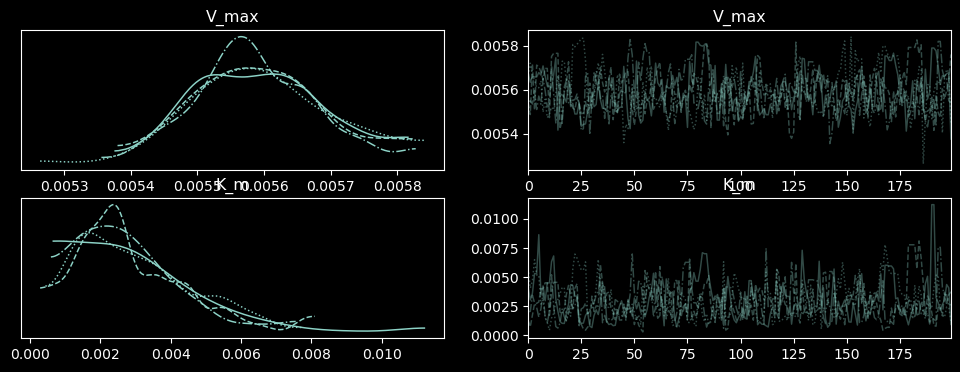

In [111]:
# Display summary
print("\n=== MCMC Summary ===")
summary = az.summary(posterior, var_names=free_params_list, round_to=6)
display(summary)

# Plot trace
az.plot_trace(posterior, var_names=free_params_list)
print("\nTrace plots generated")